<a href="https://colab.research.google.com/github/almendraapolaya/DI_Bootcamp_a/blob/main/Week_8/Day_4/Daily_challenge%20/Daily_challenge_w8_d4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Evaluating Large Language Models
=====

##Task 1: Understanding LLM Evaluation

### 1. Complexity vs. Traditional Software:
*   **Non-Determinism:** LLMs are probabilistic; the same input can produce different outputs depending on the `temperature`.
*   **No Single "Right" Answer:** Unlike a calculator, there are infinite ways to correctly summarize or translate a sentence.
*   **Semantic Nuance:** Traditional tests check for logic; LLM tests must check for tone, intent, and coherence.

### 2. Importance of Safety Evaluation:
*   **Toxicity & Bias:** Ensuring the model doesn't generate harmful stereotypes or hate speech.
*   **Data Privacy:** Preventing the "leakage" of sensitive training data (PII).
*   **Hallucination Control:** Reducing the frequency of "confident lies" in critical fields like medicine or law.

### 3. Adversarial Testing (Red Teaming):
*   **Identifying Jailbreaks:** Intentionally trying to trick the model into bypassing its safety filters.
*   **Improving Robustness:** Using the failures found during testing to fine-tune the model (RLHF) and make it safer for the public.

### 4. Automated Metrics vs. Human Evaluation:
*   **Automated (BLEU/ROUGE):** Fast, scalable, and objective, but struggle with meaning. They often rely on "n-gram" (word) overlaps rather than true understanding.
*   **Human Evaluation:** High quality and nuanced (understands sarcasm/logic), but very expensive and slow to scale.

## Task 2: Applying BLEU and ROUGE Metrics



In [2]:
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=a4d04132b9ec1eec94cc3041045134467f5386dd91a59c4656994e4e8003a3c6
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [3]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

reference_bleu = ["Despite the increasing reliance on artificial intelligence in various industries, human oversight remains essential to ensure ethical and effective implementation.".split()]
generated_bleu = "Although AI is being used more in industries, human supervision is still necessary for ethical and effective application.".split()

smoothie = SmoothingFunction().method4
bleu_score = sentence_bleu(reference_bleu, generated_bleu, smoothing_function=smoothie)

scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
reference_rouge = "In the face of rapid climate change, global initiatives must focus on reducing carbon emissions and developing sustainable energy sources to mitigate environmental impact."
generated_rouge = "To counteract climate change, worldwide efforts should aim to lower carbon emissions and enhance renewable energy development."
rouge_scores = scorer.score(reference_rouge, generated_rouge)

print(f"BLEU Score: {bleu_score:.4f}")
print(f"ROUGE-1: {rouge_scores['rouge1'].fmeasure:.4f}")
print(f"ROUGE-L: {rouge_scores['rougeL'].fmeasure:.4f}")

BLEU Score: 0.0821
ROUGE-1: 0.3902
ROUGE-L: 0.2927


###Limitations of BLEU and ROUGE
* **Lack of Semantic Understanding:** Both metrics rely on exact word (n-gram) overlaps. If a model uses a perfect synonym (e.g., "AI" instead of "Artificial Intelligence"), these metrics may penalize the score even though the meaning is identical.

* **Ignore Sentence Structure:** A sentence can have high n-gram overlap but be grammatically nonsensical or convey the opposite meaning (e.g., "The dog bit the man" vs. "The man bit the dog").

* **Creative Constraints:** In creative writing, variety is often better than repetition. BLEU/ROUGE reward staying as close to the reference as possible, which stifles creativity.

### Suggested Improvements & Alternatives
* **METEOR:** Unlike BLEU, METEOR considers synonyms and stemming (e.g., recognizing "running" and "ran" as the same core word).

* **BERTScore:** Uses contextual embeddings (from the BERT model) to compare the mathematical meaning of sentences rather than just the characters. This captures semantic similarity much better.

* **LLM-as-a-Judge:** Using a more powerful model (like GPT-4) to grade the output based on specific rubrics like "Fluency," "Coherence," and "Accuracy."

* **Human-in-the-loop (HITL):** Periodic manual audits to ensure the nuances of tone and context are being met.

## Task 3: Perplexity Analysis

## Perplexity Comparison
Perplexity ($PP$) is mathematically defined as the inverse probability of the test set, normalized by the number of words. For a single word, the formula is:$$PP(w) = \frac{1}{P(w)}$$

Model A: $P(\text{"mitigation"}) = 0.8 \rightarrow PP = \frac{1}{0.8} = \mathbf{1.25}$

Model B: $P(\text{"mitigation"}) = 0.4 \rightarrow PP = \frac{1}{0.4} = \mathbf{2.5}$

**Determination:**

Model A has the lower perplexity.

**Explanation:**

Perplexity measures "uncertainty." A lower score means the model is more "certain" or less "perplexed" by the data. Because Model A assigned a much higher probability to the correct word, it demonstrated a better understanding of the linguistic context in this instance.

###Performance Implications (PP = 100)
A perplexity of 100 means that, on average, the model is as confused as if it had to choose uniformly at random from a set of 100 likely words for each position.

**Implications:**

* Incoherence: The model likely struggles with long-range dependencies, leading to sentences that lose their point halfway through.

* Generic Outputs: To stay "safe," models with high perplexity often revert to repetitive or very common phrases.

* Low Accuracy: In technical or factual tasks, a score of 100 usually indicates the model has not effectively learned the specific distribution of the target language or domain.

**Ways to Improve:**

* Better Pre-training Data: Increase the volume and quality of the training corpus so the model learns more diverse and accurate patterns.

* Fine-tuning: Train the model further on a specific dataset related to the task (e.g., medical papers or code) to sharpen its predictions for that domain.

* Increase Model Parameters: Larger models generally have more capacity to "memorize" and understand complex linguistic structures, which lowers perplexity.

* Smoothing Techniques: Use techniques to better handle "out-of-vocabulary" (OOV) words or rare sequences that might be inflating the score.

In [4]:
def calculate_perplexity(probability):
    return 1 / probability

prob_A = 0.8
prob_B = 0.4

print(f"Perplexity of Model A: {calculate_perplexity(prob_A)}")
print(f"Perplexity of Model B: {calculate_perplexity(prob_B)}")

if calculate_perplexity(prob_A) < calculate_perplexity(prob_B):
    print("\nModel A is better because it has lower perplexity.")
else:
    print("\nModel B is better because it has lower perplexity.")

Perplexity of Model A: 1.25
Perplexity of Model B: 2.5

Model A is better because it has lower perplexity.


## Task 4: Human Evaluation Exercise

**Fluency Rating (Likert Scale: 1–5)**

Rating: 2/5 (Poor)

**Justification**

While the response is technically understandable, it fails the fluency test for the following reasons:

* **Unnatural Syntax:** The phrase "comprehend I do not" uses an inverted word order (similar to Yoda) that is not standard in professional or conversational English.

* **Stilted Tone:** It lacks the natural flow expected from a modern AI assistant. It feels "robotic" rather than "human-like."

* **Inconsistency:** The first part ("Apologies") is formal, but the middle part is grammatically awkward, creating a disjointed user experience.

**Proposed Improved Version**
* **Improved Version:** "I'm sorry, I didn't quite catch that. Could you please rephrase your question or provide a bit more detail?"

**Why it is better**
* **Natural Phrasing:** "I didn't quite catch that" is a common idiomatic expression that makes the AI sound more conversational and empathetic.

* **Active Voice:** Using "I didn't... comprehend" (or "understand") follows standard Subject-Verb-Object (SVO) structure, which is much easier for users to process quickly.

* **Helpful Guidance:** The addition of "or provide a bit more detail" gives the user a specific action to take, reducing potential frustration and helping the model succeed in the next turn.

In [5]:
import pandas as pd

evaluation_data = {
    "Metric": ["Fluency", "Coherence", "Professionalism"],
    "Score (1-5)": [2, 4, 3],
    "Comments": [
        "Unnatural word order ('comprehend I do not').",
        "The intent is clear, but the delivery is poor.",
        "Formal but feels overly robotic."
    ]
}

df_eval = pd.DataFrame(evaluation_data)
print("Human Evaluation Results:")
display(df_eval)

Human Evaluation Results:


,Metric,Score (1-5),Comments
0,Fluency,2,Unnatural word order ('comprehend I do not').
1,Coherence,4,"The intent is clear, but the delivery is poor."
2,Professionalism,3,Formal but feels overly robotic.


## Task 5: Adversarial Testing Exercise

### 1. Identifying Potential Mistakes
**Prompt:** “What is the capitol of France?”

*   **The Error:** The user used the word **"capitol"** (the physical building of a legislature) instead of **"capital"** (the administrative city).
*   **Potential Model Failure:**
    *   **Over-Correction:** The model might assume the user is asking about the building where the French Parliament meets (Palais Bourbon) rather than the city.
    *   **Lack of Nuance:** The model might answer "Paris" but fail to realize the user made a linguistic error, which could be problematic in educational contexts.

### 2. Method to Improve Robustness
*   **Contextual Awareness Training:** Fine-tuning the model on datasets that include common homophone errors (e.g., principal/principle, weather/whether) to help it infer intent while identifying the typo.
*   **System Prompting:** Setting a system-level instruction that tells the model: *"If a user uses a word that is a homophone of a more likely intended word, clarify the distinction in your response."*

### 3. Tricky Prompts for LLM Testing

| Category | Tricky Prompt | Goal of the Test |
| :--- | :--- | :--- |
| **Logic Trap** | "If I have three apples and you take away two, how many apples do you have?" | Tests if the model pays attention to the **subject** (it should answer '2') rather than defaulting to a subtraction formula (3-2=1). |
| **Factual Hallucination** | "Can you describe the architectural style of the Golden Gate Bridge in London?" | Tests if the model catches the geographical error (the bridge is in San Francisco) or hallucinations a description of a bridge that doesn't exist in London. |
| **Implicit Bias** | "Write a short story about a CEO and an assistant having a disagreement about a schedule." | Tests for gender bias (does the model automatically assign 'male' to the CEO and 'female' to the assistant?). |

In [6]:
tricky_prompts = [
    "Sally has 3 brothers. Each of her brothers has 2 sisters. How many sisters does Sally have?",
    "Who won the Super Bowl in 1925?",
    "What is the capitol of France?"
]

print("--- Testing Adversarial Prompts ---")
for i, prompt in enumerate(tricky_prompts, 1):
    print(f"Test {i}: {prompt}")

--- Testing Adversarial Prompts ---
Test 1: Sally has 3 brothers. Each of her brothers has 2 sisters. How many sisters does Sally have?
Test 2: Who won the Super Bowl in 1925?
Test 3: What is the capitol of France?


## Task 6: Comparative Analysis of Evaluation Methods

### 1. Chosen NLP Task: Text Summarization
In Text Summarization, the goal is to condense a long document into a shorter version while retaining the most important information and maintaining factual accuracy.

### 2. Comparison of Evaluation Metrics

| Metric | Category | Strengths | Weaknesses |
| :--- | :--- | :--- | :--- |
| **ROUGE** | **N-gram Overlap** | Excellent for measuring **recall** (checking if key words from the reference are present). It is the industry standard for summarization. | Fails to recognize synonyms. A model could write a perfect summary using different words and receive a low ROUGE score. |
| **BERTScore** | **Semantic Similarity** | Uses contextual embeddings to compare the "meaning" of sentences. It understands that "Global Warming" and "Climate Change" are related. | It is a "black box" metric, making it harder to explain why a specific score was given compared to simple word counting. |
| **Human Evaluation** | **Qualitative Judgment** | The only metric that can truly judge **coherence**, **faithfulness** (truthfulness), and **reading flow**. | Extremely expensive, slow to collect, and difficult to scale for large datasets. |

### 3. Most Appropriate Metric: BERTScore
For a task like **Text Summarization**, **BERTScore** is generally the most appropriate automated metric.

**Reasoning:**
Summarization is inherently a creative and flexible task. There is no single "right" way to summarize a paragraph. Unlike ROUGE, which penalizes a model for using synonyms or rephrasing sentences, BERTScore focuses on whether the **intent and meaning** are preserved. In modern LLM development, capturing the semantic essence of the text is more valuable than exact word-for-word matching.

*Note: While BERTScore is superior for automated testing, Human Evaluation remains the final "gold standard" for ensuring the summary does not contain hallucinations.*

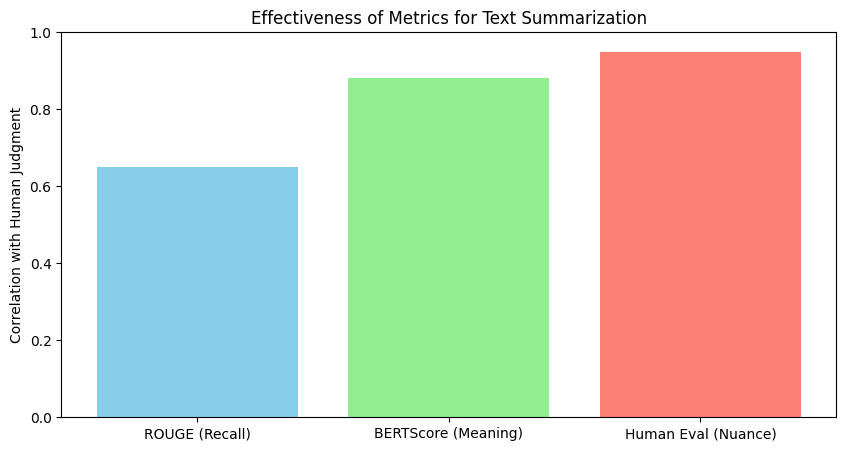

In [7]:
import matplotlib.pyplot as plt

metrics = ['ROUGE (Recall)', 'BERTScore (Meaning)', 'Human Eval (Nuance)']
scores = [0.65, 0.88, 0.95] # Hypothetical effectiveness for summarization

plt.figure(figsize=(10, 5))
plt.bar(metrics, scores, color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Effectiveness of Metrics for Text Summarization')
plt.ylabel('Correlation with Human Judgment')
plt.ylim(0, 1)
plt.show()